<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_3_(CO2(ne%2C_Me)).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Множественная регрессия CO2(ne, Me)

In [1]:
!pip install --upgrade patsy statsmodels

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# Загрузка данных и конвертация в CSV
file_name = '/content/multiregress042020.xlsx'
df = pd.read_excel(file_name, header=1)
csv_file_name = 'multiregress042020.csv'
df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')


# Создаю переменные
X_data = df[['ne', 'Me']]
Y_data = df['CO2']

# Добавляем константу
X_sm = sm.add_constant(X_data)

# Проверка перых 3 строк
print(df.head(3))

   i    ne   Me    tc      ge    CO2     NOx
0  1  1200  140  80.7  233.16   5.88  665.25
1  2  1200  210  82.8  225.23   8.67  900.50
2  3  1200  252  83.2  232.83  10.58  957.19


In [4]:
# Построение модели
model_co2 = sm.OLS(Y_data, X_sm).fit()

# Вывод результатов
print(model_co2.summary())

# Вывод критерия Дарбина-Уотсона
dw_stat = sm.stats.stattools.durbin_watson(model_co2.resid)
print(f"\nСтатистика Дарбина-Уотсона: {dw_stat:.3f}")
if 1.5 < dw_stat < 2.5:
    print("Вывод: Автокорреляция остатков отсутствует (значение близко к 2).")
else:
    print("Вывод: В модели присутствует автокорреляция остатков.")

                            OLS Regression Results                            
Dep. Variable:                    CO2   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     688.3
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.87e-18
Time:                        09:27:47   Log-Likelihood:                -7.1647
No. Observations:                  22   AIC:                             20.33
Df Residuals:                      19   BIC:                             23.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4605      0.549     -0.839      0.4

/tmp/ipykernel_23700/224617936.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  z_surf = model_co2.params[0] + model_co2.params[1]*x_surf + model_co2.params[2]*y_surf


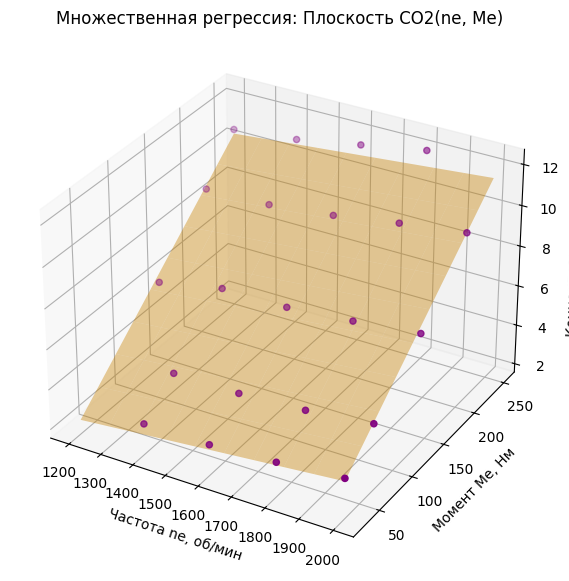

In [5]:
# Визуализация
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Точки
ax.scatter(df['ne'], df['Me'], df['CO2'], color='purple', label='Фактические данные')

# Сетка
x_surf, y_surf = np.meshgrid(np.linspace(df['ne'].min(), df['ne'].max(), 10),
                             np.linspace(df['Me'].min(), df['Me'].max(), 10))
# Формула регрессии
z_surf = model_co2.params[0] + model_co2.params[1]*x_surf + model_co2.params[2]*y_surf

# Плоскость
ax.plot_surface(x_surf, y_surf, z_surf, color='orange', alpha=0.4)

ax.set_xlabel('Частота ne, об/мин')
ax.set_ylabel('Момент Me, Нм')
ax.set_zlabel('Концентрация CO2, %')
plt.title('Множественная регрессия: Плоскость CO2(ne, Me)')
plt.show()